# Vertical integration for spatialmeta

# Loading data & Preprocessing

## Import statements

This tutorial demonstrates the process of vertically integrating spatial transcriptomics (ST) and spatial metabolomics (SM) data using spatialMETA.

In [29]:
import seaborn as sns
import spatialmeta as smt
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

## Downloading and storing data

In this section, we read and preprocess the joint SM and ST data. The steps include removing unwanted genes, normalizing the data, identifying spatial variable genes and metabolites, and selecting the subset of spatial variable genes and metaboliyes for further analysis.

Load the AnnData object for the given sample name and modality.

Parameters: <br>
**sample_name** – str The name of the sample. Use list_datasets to get the list of all available datasets. <br>
**modality** – Literal[“ST”, “SM”, “joint”] The modality of the dataset. Choose from “ST”, “SM”, or “joint”. <br>

In [30]:
smt.data.list_datasets()

,url,file_name
0,/records/14986870/files/adata_joint_R114_T_raw...,adata_joint_R114_T_raw.h5ad
1,/records/14986870/files/adata_joint_S15_T_raw....,adata_joint_S15_T_raw.h5ad
2,/records/14986870/files/adata_joint_X49_T_raw....,adata_joint_X49_T_raw.h5ad
3,/records/14986870/files/adata_joint_Y27_T_raw....,adata_joint_Y27_T_raw.h5ad
4,/records/14986870/files/adata_joint_Y7_T_raw.h...,adata_joint_Y7_T_raw.h5ad
5,/records/14986870/files/adata_SM_R114_T_raw.h5...,adata_SM_R114_T_raw.h5ad
6,/records/14986870/files/adata_SM_S15_T_raw.h5a...,adata_SM_S15_T_raw.h5ad
7,/records/14986870/files/adata_SM_X49_T_raw.h5a...,adata_SM_X49_T_raw.h5ad
8,/records/14986870/files/adata_SM_Y27_T_raw.h5a...,adata_SM_Y27_T_raw.h5ad
9,/records/14986870/files/adata_SM_Y7_T_raw.h5ad...,adata_SM_Y7_T_raw.h5ad


In [31]:
joint_adata = smt.data.load_adata(
    sample_name="Y7_T_raw",
    modality="joint"
)

joint_adata.write_h5ad("SpatialMETA/data/Y7_T_joint.h5ad")

# mouse_adata = smt.data.load_adata(
#     sample_name="Y7_T_raw.aligned",
#     modality="joint"
# )

# mouse_adata.write_h5ad("SpatialMETA/data/Y7_T_mouse.h5ad")

/home/mnxsybi_lumc/.conda/envs/spatial/lib/python3.9/site-packages/spatialmeta/data/./datasets/adata_joint_Y7_T_raw_raw.h5ad


## Preprocessing

removing unwanted genes (Not listed on spatialmeta docs). <br>
pp. stands for preprocessing


In [32]:
joint_adata = smt.pp.removeHSP_MT_RPL_DNAJ(joint_adata)

In [33]:
joint_adata.layers["counts"] = joint_adata.X.copy()

Normalize the total intensity of the SM and ST data in the joint AnnData object.

Parameters: <br>
**joint_adata** – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**target_sum_SM** – Optional[int]. The target sum for SM data, default is 1e4. <br>
**target_sum_ST** – Optional[int]. The target sum for ST data, default is 1e4. <br>

In [34]:
smt.pp.normalize_total_joint_adata_sm_st(joint_adata,
                         target_sum_SM=1e4,
                         target_sum_ST=1e4)

In [35]:
joint_adata.layers["normalized"] = joint_adata.X.copy()

In [36]:
joint_adata.raw = joint_adata

Calculate the spatial variables for the joint AnnData object and remove the batch-specific spatial variables.

Parameters: <br>
joint_adata – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**n_top_genes** – int. The number of top genes, default is 2000. <br>
**n_top_metabolites** – int. The number of top metabolites, default is 800. <br>
**add_key** – str. The key for the spatial variables, default is “highly_variable_moranI”. <br>
batch_key – Optional[str]. The batch key, default is None. <br>
min_samples – int. The minimum number of samples, default is 2. <br>
min_frac – float. The minimum fraction, default is 0.8. <br>
min_logfc – float. The minimum log fold change, default is 3. <br>

In [9]:
smt.pp.spatial_variable_joint_adata_sm_st(joint_adata,
                                         n_top_genes = 2000,
                                         n_top_metabolites = 800,
                                         add_key = "highly_variable_moranI")

In [10]:
joint_adata = joint_adata[:,joint_adata.var.highly_variable_moranI]

In [11]:
joint_adata.write_h5ad("SpatialMETA/data/Y7_T_adata_joint_hvf2800.h5ad")

# ConditionalVAE model for vertical integration

In this section, we train a ConditionalVAE model on the preprocessed joint SM and ST data. The VAE model learns a low-dimensional representation of the data that captures the underlying structure and relationships between the SM and ST measurements.

In [12]:
joint_adata = sc.read_h5ad("SpatialMETA/data/Y7_T_adata_joint_hvf2800.h5ad")

In [13]:
joint_adata.X = joint_adata.layers["counts"]

Normalize the total intensity of the SM and ST data in the joint AnnData object.

Parameters: <br>
**joint_adata** – AnnDataJointSMST. The joint AnnData object with SM and ST data. <br>
**target_sum_SM** – Optional[int]. The target sum for SM data, default is 1e4. <br>
**target_sum_ST** – Optional[int]. The target sum for ST data, default is 1e4. <br>

In [14]:
smt.pp.normalize_total_joint_adata_sm_st(
    joint_adata,
    target_sum_SM=1e3,
    target_sum_ST=None
)

This class implements a Conditional Variational Autoencoder with Mixture of Experts (MoE) for vertical and horizontal integration of ST and SM.

Parameters: <br>
adata – AnnDataJointSMST object containing the spatial multi-omics data. <br>
hidden_stacks – List of integers specifying the number of hidden units in each stack of the encoder and decoder, default is [128]. <br>
batch_keys – Optional list of strings specifying the batch keys for batch correction. <br>
n_latent – Integer specifying the dimensionality of the latent space, default is 10. <br>
bias – Boolean indicating whether to include bias terms in the linear layers, default is True. <br>
use_batch_norm – Boolean indicating whether to use batch normalization in the linear layers, default is True. <br>
use_layer_norm – Boolean indicating whether to use layer normalization in the linear layers, default is False. <br>
dropout_rate – Float specifying the dropout rate for the linear layers, default is 0.1. <br>
activation_fn – Callable specifying the activation function to use in the linear layers, default is nn.ReLU. <br>
**device** – String or torch.device specifying the device to use for computation, default is “cpu”. <br>
batch_embedding – Literal[“embedding”, “onehot”] specifying the type of batch embedding to use, default is “onehot”. <br>
encode_libsize – Boolean indicating whether to encode library size information, default is False. <br>
batch_hidden_dim – Integer specifying the dimensionality of the batch hidden layer, default is 8. <br>
**reconstruction_method_st** – Literal[‘mse’, ‘zg’, ‘zinb’] specifying the reconstruction method for the spatial data, default is ‘zinb’. <br>
**reconstruction_method_sm** – Literal[‘mse’, ‘zg’, ‘g’] specifying the reconstruction method for the single-cell multi-omics data, default is ‘g’. <br>

In [15]:
model = smt.model.ConditionalVAESTSM(
    joint_adata,
    device='cpu', # Small change to CPU instead of CUDA
    reconstruction_method_sm='g',
    reconstruction_method_st='zinb',
)

Fits the model.

Parameters: <br>
**max_epoch** – Integer specifying the maximum number of epochs to train the model, default is 35. <br>
n_per_batch – Integer specifying the number of samples per batch, default is 128. <br>
**mode** – Optional string specifying the mode of training. Can be either ‘single’ or ‘multi’, default is None. <br>
reconstruction_reduction – String specifying the reduction method for the reconstruction loss, default is ‘sum’. <br>
kl_weight – Float specifying the weight of the KL divergence loss, default is 1. <br>
reconstruction_st_weight – Float specifying the weight of the reconstruction loss for spatial transcriptomics, default is 1. <br>
reconstruction_sm_weight – Float specifying the weight of the reconstruction loss for single-cell multi-omics, default is 1. <br>
reconstruction_st_corr_weight – Float specifying the weight of the correlation reconstruction loss for spatial transcriptomics, default is 1. <br>
reconstruction_sm_corr_weight – Float specifying the weight of the correlation reconstruction loss for single-cell multi-omics, default is 1. <br>
n_epochs_kl_warmup – Integer specifying the number of epochs for KL divergence warmup, default is 400. <br>
optimizer_parameters – Iterable specifying the parameters for the optimizer, default is None. <br>
weight_decay – Float specifying the weight decay for the optimizer, default is 1e-6. <br>
**lr** – Float specifying the learning rate for the optimizer. <br>
random_seed – Integer specifying the random seed, default is 12. <br>
kl_loss_reduction – String specifying the reduction method for the KL divergence loss, default is ‘mean’. <br>
mmd_weight – Float specifying the weight of the MMD loss, default is 1. <br>

Returns: <br>
Dictionary containing the training loss values. <br>

In [16]:
loss_dict = model.fit(
    max_epoch=400,
    lr=1e-3,
    mode='single'
)

Epoch 400: 100%|██████████| 400/400 [03:42<00:00,  1.80it/s, reconst_sm=-1.19e+02, reconst_st=3.15e+02, reconst_sm_corr=-1.23e+02, reconst_st_corr=3.15e+02, kldiv=5.44e+00, total_loss=2.91e+03, mmd_loss=0.00e+00]


## Loss visualisation

In this section, we visualize the loss during the training of the ConditionalVAE model. The loss consists of three components: Kullback-Leibler divergence loss, reconstruction loss for spatial metabolomics (SM), and reconstruction loss for spatial transcriptomics (ST).

findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.


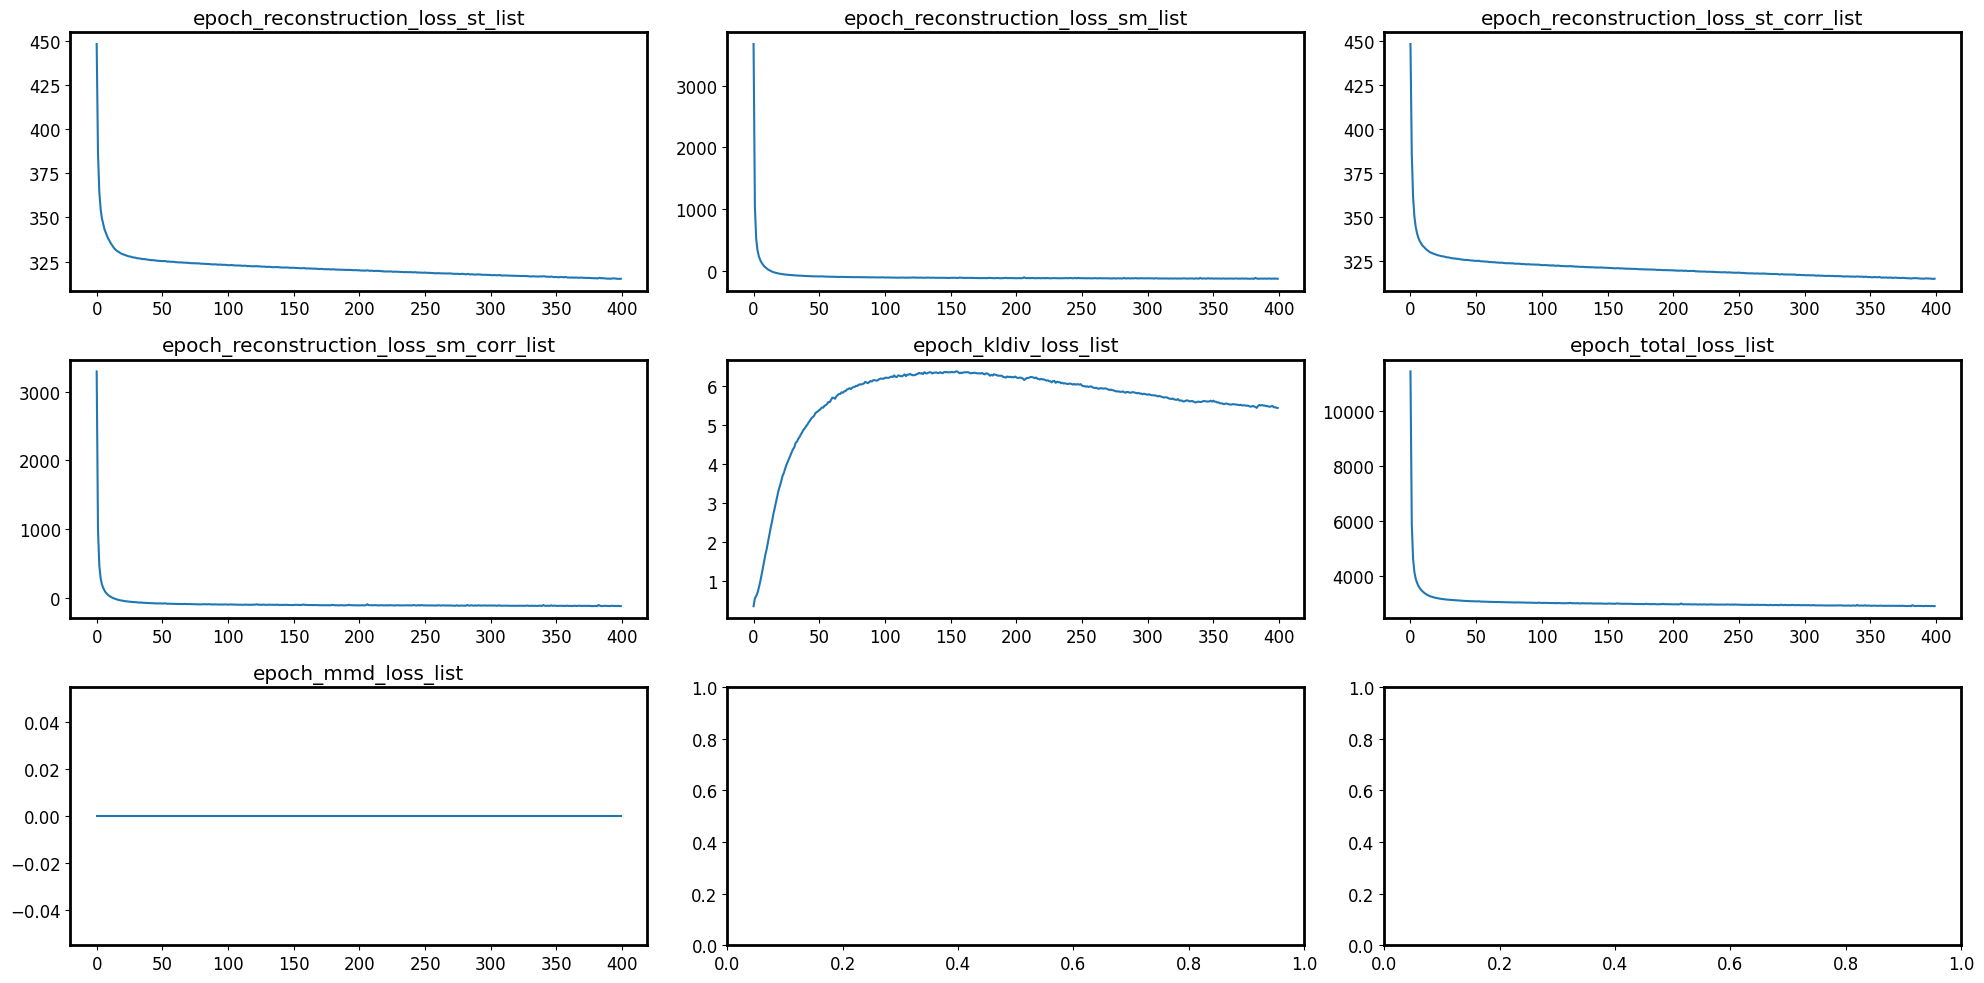

In [17]:
fig,axes = plt.subplots(3, 3, figsize=(20,10))
axes = axes.flatten()

for ax, (k, v) in zip(axes, loss_dict.items()):
    ax.plot(v)
    ax.set_title(k)

plt.tight_layout()
plt.show()

## Visualisation and analysis

In this section, we visualize the results of the vertical integration using various plots and analysis techniques. We plot the loss curves during model training, visualize the latent space using UMAP, and explore the spatial patterns of specific genes or metabolites after denoising.

In [18]:
Z = model.get_latent_embedding()
X = model.get_normalized_expression()
C = model.get_modality_contribution()

Latent Embedding: 100%|██████████| 15/15 [00:00<00:00, 169.93it/s]


In [19]:
joint_adata.layers['reconstruction'] = X
joint_adata.obsm['X_emb']=Z
joint_adata.obs['contribution_st']=C
joint_adata.obs['contribution_sm']=1-C

Compute the nearest neighbors distance matrix and a neighborhood graph of observations

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**use_rep** (str) - Use the indicated representation. 'X' or any key for .obsm is valid. <br>
**n_neighbors** (int) - The size of local neighborhood (in terms of number of neighboring data points) used for manifold approximation. Larger values result in more global views of the manifold, while smaller values result in more local data being preserved. <br>

In [20]:
sc.pp.neighbors(
    joint_adata,
    use_rep="X_emb",
    n_neighbors=15
)

Embed the neighborhood graph using UMAP. UMAP (Uniform Manifold Approximation and Projection) is a manifold learning technique suitable for visualizing high-dimensional data. <br>

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**min_dist** (float) - The effective minimum distance between embedded points. Smaller values will result in a more clustered/clumped embedding where nearby points on the manifold are drawn closer together, while larger values will result on a more even dispersal of points. <br>
**spread** (float) - The effective scale of embedded points. In combination with min_dist this determines how clustered/clumped the embedded points are. <br>

In [21]:
sc.tl.umap(
    joint_adata,
    min_dist=1,
    spread=1
)

Cluster cells into subgroups. Cluster cells using the Leiden algorithm, an improved version of the Louvain algorithm.

Parameters: <br>
**adata** (AnnData) - Annotated data matrix. <br>
**key_added** (str) - (adata.obs) key under which to add the cluster labels. <br>


In [22]:
sc.tl.leiden(
    joint_adata,
    key_added="VAE_clusters_latent10"
)

### Cluster plot

Scatter plot in UMAP basis.
https://scanpy.scverse.org/en/stable/api/generated/scanpy.pl.umap.html#scanpy.pl.umap

findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.


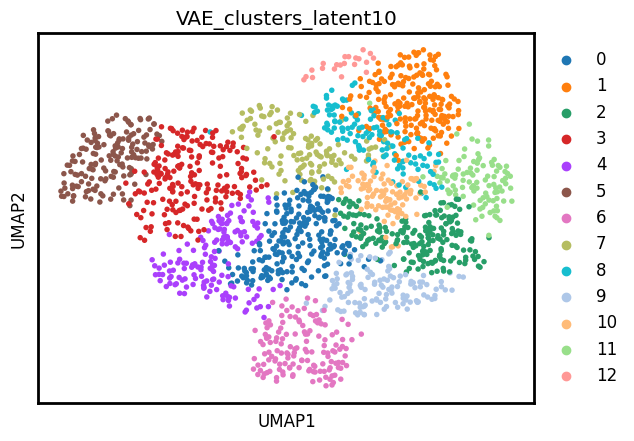

In [23]:
sc.pl.umap(
    joint_adata,
    color=["VAE_clusters_latent10"],
    show=True
)

### Hires plots

Scatter plot in spatial coordinates.
https://scanpy.scverse.org/en/stable/api/generated/scanpy.pl.spatial.html#scanpy.pl.spatial

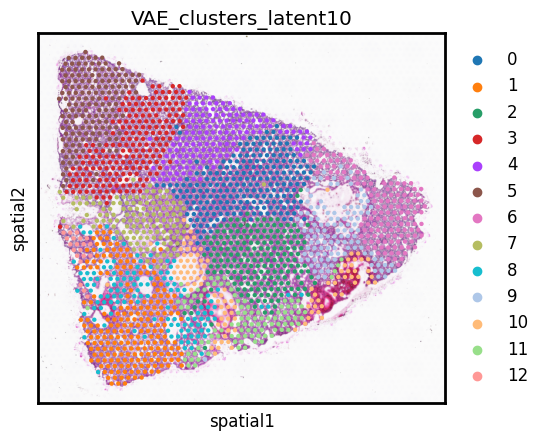

In [24]:
sc.pl.spatial(
    joint_adata,
    img_key="hires",
    color=["VAE_clusters_latent10"]
)

### Normalized plots 1 (purple)

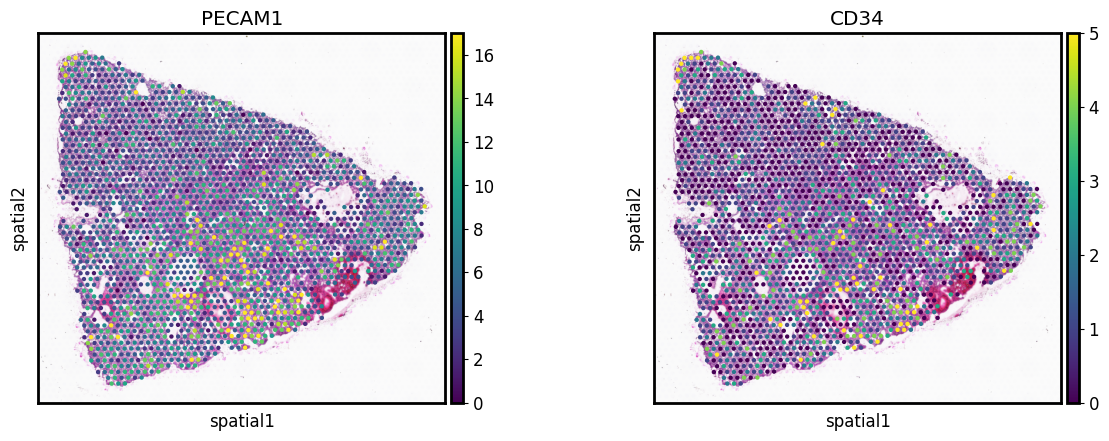

In [56]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color=["PECAM1","CD34"],
              layer="normalized",
              vmax="p98",   # cap at 99th percentile
              vmin="p0")

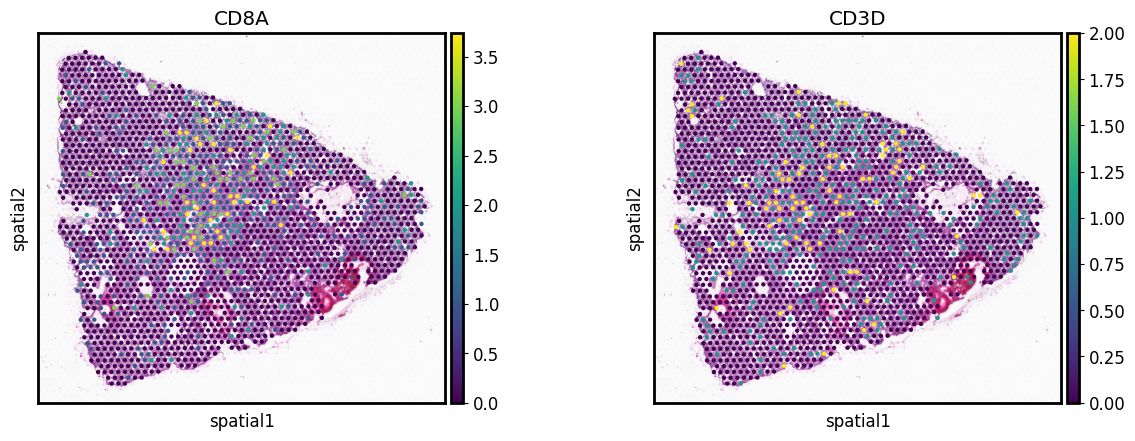

In [57]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color=["CD8A","CD3D"],
              layer="normalized",
              vmax="p98",   # cap at 99th percentile
              vmin="p0")

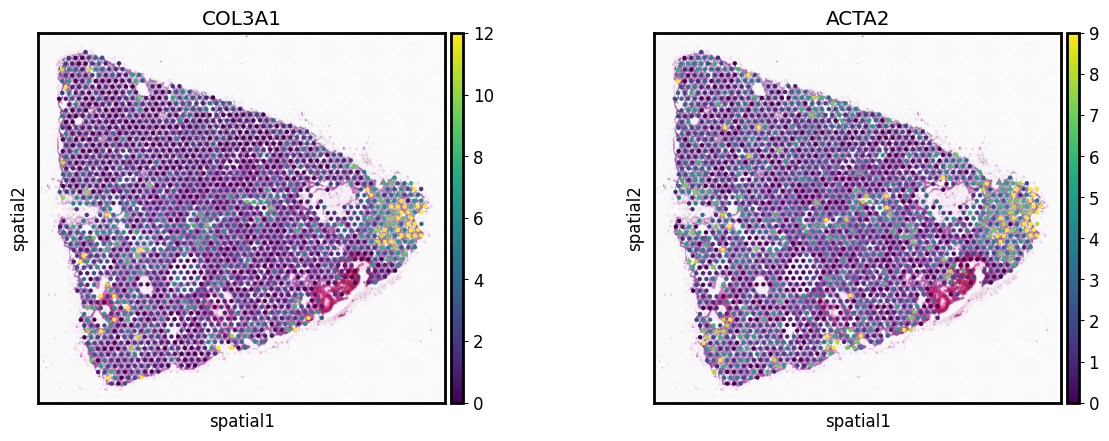

In [58]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color=["COL3A1","ACTA2"],
              layer="normalized",
              vmax="p98",   # cap at 99th percentile
              vmin="p0")

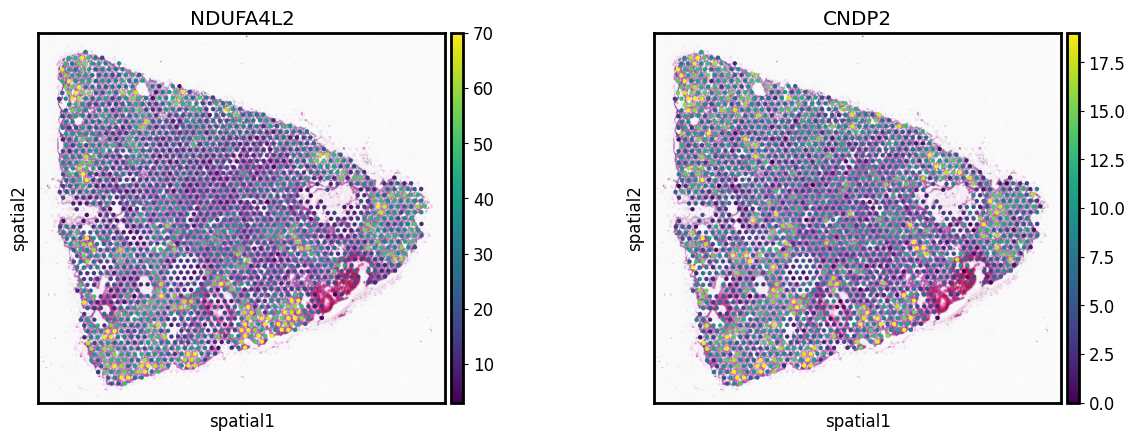

In [59]:
sc.pl.spatial(joint_adata,
              #img_key="hires",
              color=["NDUFA4L2","CNDP2"],
              layer="counts",
              vmax="p98",   # cap at 99th percentile
              vmin="p0")

In [27]:
print(joint_adata)

AnnData object with n_obs × n_vars = 1914 × 2800
    obs: 'x_coord', 'y_coord', 'spot_name', 'total_intensity', 'mean_intensity', 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'contribution_st', 'contribution_sm', 'VAE_clusters_latent10'
    var: 'name', 'type', 'highly_variable_moranI'
    uns: 'spatial', 'neighbors', 'umap', 'leiden', 'VAE_clusters_latent10_colors'
    obsm: 'spatial', 'X_emb', 'X_umap'
    layers: 'counts', 'normalized', 'reconstruction'
    obsp: 'distances', 'connectivities'


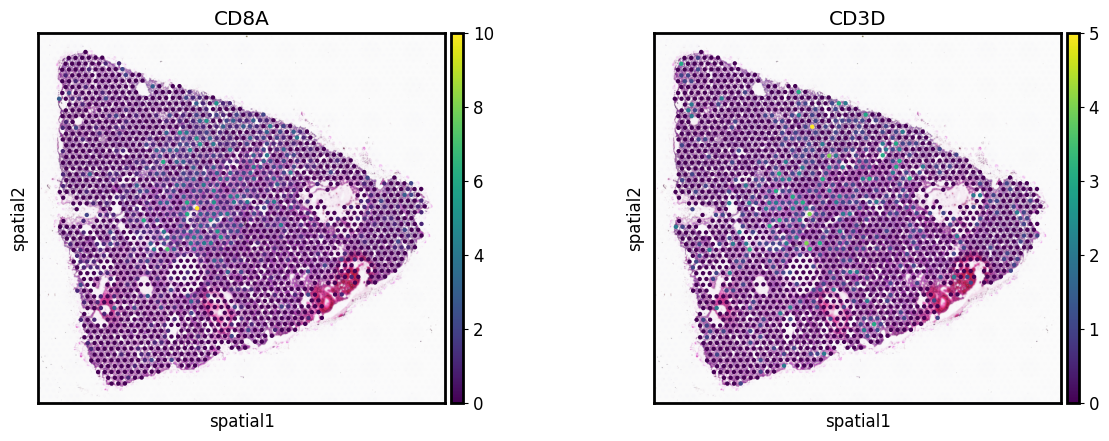

In [28]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color=["CD8A","CD3D"],
              layer="counts")

### Recondstructed plots

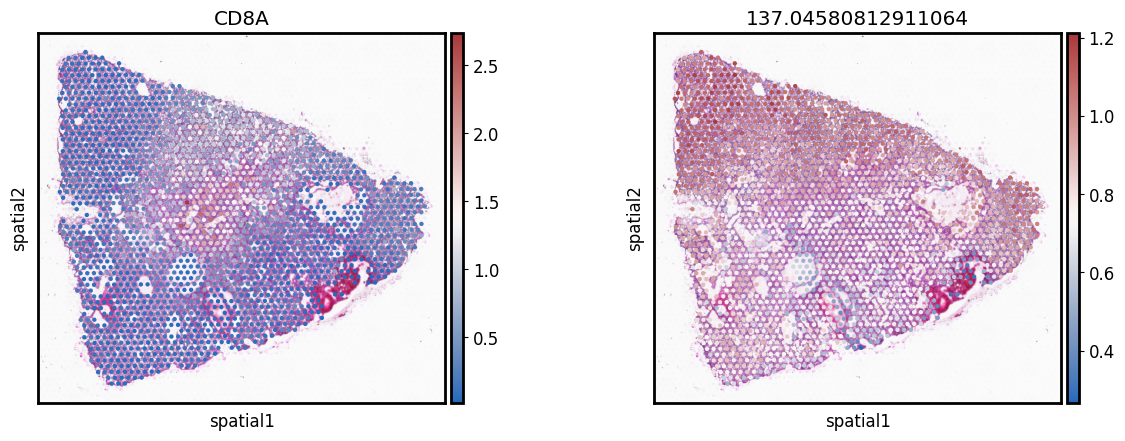

In [26]:
sc.pl.spatial(joint_adata,
              img_key="hires",
              color_map = "vlag",
              color=["CD8A","137.04580812911064"],
              layer="reconstruction")

### Normalized plots 2 (cyan)

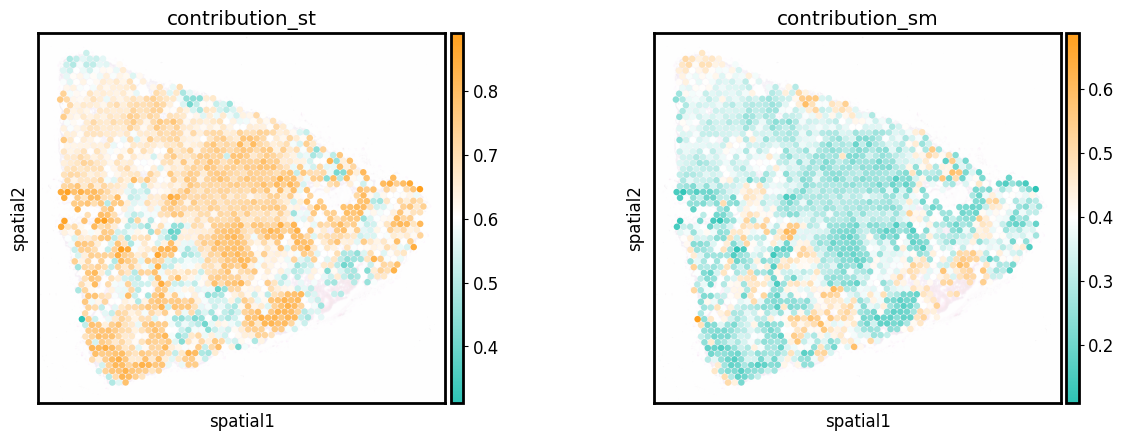

In [27]:
sc.pl.spatial(
    joint_adata,
    img_key="hires",
    color_map = smt.pl.make_colormap(['#2ec4b6','#ffffff','#ff9f1c' ]),
    color=['contribution_st','contribution_sm'],
    layer="normalized",
    alpha_img=0.1,
    size=1.5
)

### Violin plots

Create a figure with the specified size and axis properties.

Parameters: <br>
**figsize** – tuple specifying the size of the figure, default is (8, 4). <br>

Returns: <br>
figure and axis objects. <br>

A violin plot plays a similar role as a box-and-whisker plot. It shows the distribution of data points after grouping by one (or more) variables. Unlike a box plot, each violin is drawn using a kernel density estimate of the underlying distribution. <br>
https://seaborn.pydata.org/generated/seaborn.violinplot.html

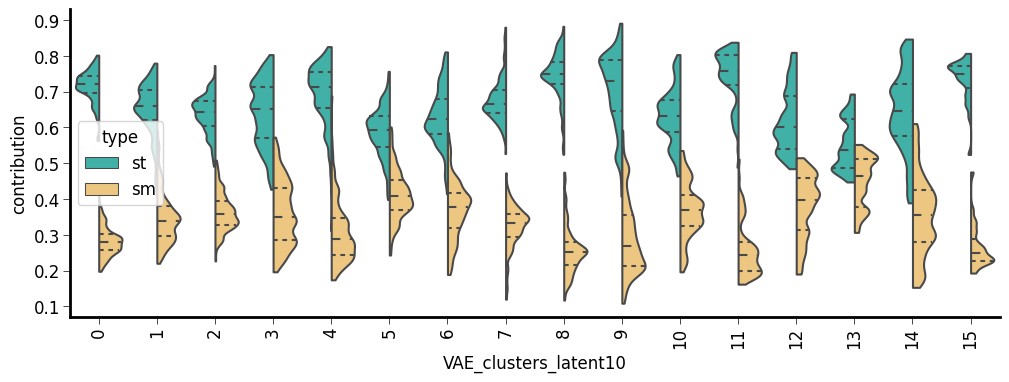

In [28]:
obs_df = joint_adata.obs
obs_filter_df = pd.concat([
    obs_df[['VAE_clusters_latent10', 'contribution_st']].rename(columns={'contribution_st': 'contribution'}).assign(type='st'),
    obs_df[['VAE_clusters_latent10', 'contribution_sm']].rename(columns={'contribution_sm': 'contribution'}).assign(type='sm')
])
fig,ax = smt.pl.create_fig(
    figsize = (12,4)
)
sns.violinplot(
    data=obs_filter_df,
    x="VAE_clusters_latent10",
    y="contribution",
    hue="type",
    split=True,
    inner="quart",
    palette=['#2ec4b6', '#FFCC70'],
    scale='width',  # Make violins the same width
    bw=0.2,         # Adjust smoothness (lower value = fatter violins)
    cut=0           # Limit the violin to data range
)

plt.xticks(rotation=90)
plt.show()

In [29]:
joint_adata.write_h5ad("SpatialMETA/data/Y7_T_adata_joint_hvf2800_spatialmeta.h5ad")

## Benchmarking metrics

### Setup

In [30]:
from multi_benmark_function import (
    compute_CHAOS, compute_PAS,
    marker_score,
    compute_ARI, compute_NMI,
    compute_ASW, compute_gt_silhouette,
    compute_clisi_graph, compute_isolated_aws,
    calculate_gene_specificity,
    logistic_regression_feature_importance,
    calculate_mutual_information
)
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

PRED_KEY = 'VAE_clusters_latent10'
EMB_KEY   = 'X_emb'
GT_KEY    = 'pathological_annotation'


/home/mnxsybi_lumc/.conda/envs/spatial/lib/python3.9/site-packages/seaborn/rcmod.py:400: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
/home/mnxsybi_lumc/.conda/envs/spatial/lib/python3.9/site-packages/setuptools/_distutils/version.py:336: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


Add ground truth label to data

In [31]:
gt_adata = sc.read_h5ad("data/06_spatialmeta_groundtruth/adata_joint_Y7_T_hvf2800.h5ad")

# Build mapping on array_row + array_col instead
gt_annotation = gt_adata.obs[['array_row', 'array_col', 'pathological_annotation']].copy()
gt_annotation['grid_key'] = (gt_annotation['array_row'].astype(str) + '_' + 
                              gt_annotation['array_col'].astype(str))
gt_annotation = gt_annotation.set_index('grid_key')

# Same key on your data
joint_adata.obs['grid_key'] = (joint_adata.obs['array_row'].astype(str) + '_' + 
                                joint_adata.obs['array_col'].astype(str))

# Transfer annotation
joint_adata.obs['pathological_annotation'] = (
    joint_adata.obs['grid_key']
               .map(gt_annotation['pathological_annotation'])
)
joint_adata.obs['pathological_annotation'] = (
    joint_adata.obs['pathological_annotation'].astype('category')
)

# Clean up the helper column
joint_adata.obs.drop(columns=['grid_key'], inplace=True)

print(joint_adata.obs['pathological_annotation'].isna().sum(), "spots without annotation")
print(joint_adata.obs['pathological_annotation'].value_counts())

13 spots without annotation
0     276
1     211
12    196
5     188
11    160
2     159
3     121
4     111
7     110
14    107
13     85
8      50
10     49
9      48
6      30
Name: pathological_annotation, dtype: int64


Missing spots in ground truth

2026-06-18 14:09:49,941 - WARNING - findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.
2026-06-18 14:09:50,058 - WARNING - findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.


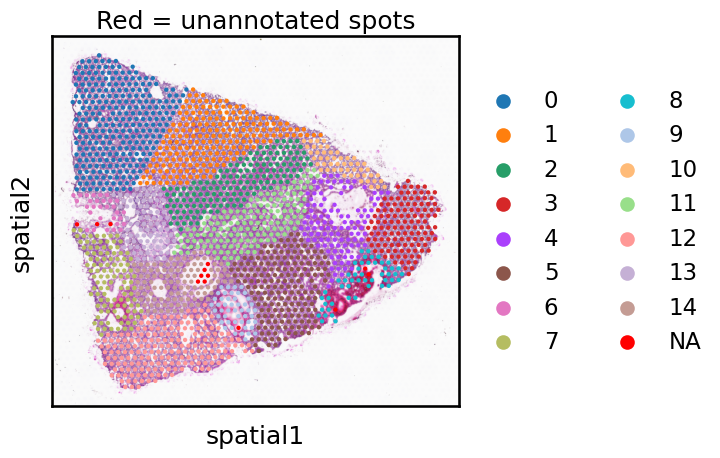

In [32]:
missing_mask = joint_adata.obs['pathological_annotation'].isna()

# Plot their spatial location
sc.pl.spatial(joint_adata, color='pathological_annotation', 
              na_color='red', title='Red = unannotated spots')

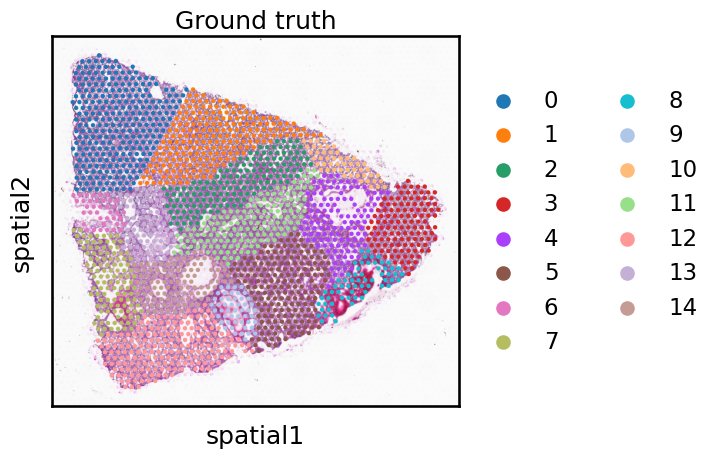

In [33]:
sc.pl.spatial(gt_adata, color='pathological_annotation', 
              na_color='red', title='Ground truth')

In [34]:
missing_mask = joint_adata.obs['pathological_annotation'].isna()
joint_adata_annotated = joint_adata[~missing_mask].copy()

# Remove NaN from the category levels themselves (categorical dtype retains them)
joint_adata_annotated.obs['pathological_annotation'] = (
    joint_adata_annotated.obs['pathological_annotation']
                         .cat.remove_unused_categories()
)

print(f"Spots for GT metrics: {joint_adata_annotated.n_obs}")
print(joint_adata_annotated.obs['pathological_annotation'].value_counts())

Spots for GT metrics: 1901
0     276
1     211
12    196
5     188
11    160
2     159
3     121
4     111
7     110
14    107
13     85
8      50
10     49
9      48
6      30
Name: pathological_annotation, dtype: int64


### Reconstruction accuracy

PCC & cosine similarity

In [35]:
import numpy as np
import scipy.sparse as sp
from scipy.stats import pearsonr

def compute_mean_pcc(adata, original_layer='counts', reconstruction_layer='reconstruction'):
    """
    Compute mean Pearson Correlation Coefficient across features (genes/metabolites).
    
    For each feature, correlates its expression vector across all spots
    between the original and reconstructed matrices, then takes the mean.
    
    Parameters
    ----------
    adata : AnnData
    original_layer : str
        Layer containing raw/original counts
    reconstruction_layer : str
        Layer containing VAE reconstructed values

    Returns
    -------
    float : mean PCC across all features
    """
    def to_dense(X):
        return X.toarray() if sp.issparse(X) else np.array(X)

    X_orig  = to_dense(adata.layers[original_layer])   # shape: (n_spots, n_features)
    X_recon = to_dense(adata.layers[reconstruction_layer])

    # Correlate column-wise (per feature across all spots)
    pccs = []
    for j in range(X_orig.shape[1]):
        feature_orig  = X_orig[:, j]
        feature_recon = X_recon[:, j]

        # Skip constant features — pearsonr is undefined for zero-variance vectors
        if feature_orig.std() == 0 or feature_recon.std() == 0:
            continue

        r, _ = pearsonr(feature_orig, feature_recon)
        pccs.append(r)

    n_skipped = X_orig.shape[1] - len(pccs)
    if n_skipped > 0:
        print(f"Skipped {n_skipped} constant features (zero variance)")

    mean_pcc = float(np.nanmean(pccs))
    print(f"Mean PCC across {len(pccs)} features: {mean_pcc:.4f}")
    return mean_pcc

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_mean_cs(adata, original_layer='counts', reconstruction_layer='reconstruction'):
    """
    Compute mean Cosine Similarity across features (genes/metabolites).
    
    For each feature, computes cosine similarity between its expression 
    vector across all spots in the original vs reconstructed matrices,
    then takes the mean.
    
    Parameters
    ----------
    adata : AnnData
    original_layer : str
        Layer containing raw/original counts
    reconstruction_layer : str
        Layer containing VAE reconstructed values

    Returns
    -------
    float : mean cosine similarity across all features
    """
    def to_dense(X):
        return X.toarray() if sp.issparse(X) else np.array(X)

    X_orig  = to_dense(adata.layers[original_layer])   # shape: (n_spots, n_features)
    X_recon = to_dense(adata.layers[reconstruction_layer])

    # Transpose so each row is a feature vector across spots: (n_features, n_spots)
    X_orig_T  = X_orig.T
    X_recon_T = X_recon.T

    similarities = []
    for j in range(X_orig_T.shape[0]):
        feature_orig  = X_orig_T[j].reshape(1, -1)
        feature_recon = X_recon_T[j].reshape(1, -1)

        # Skip zero vectors — cosine similarity undefined
        if np.linalg.norm(feature_orig) == 0 or np.linalg.norm(feature_recon) == 0:
            continue

        cs = cosine_similarity(feature_orig, feature_recon)[0, 0]
        similarities.append(cs)

    n_skipped = X_orig_T.shape[0] - len(similarities)
    if n_skipped > 0:
        print(f"Skipped {n_skipped} zero-vector features")

    mean_cs = float(np.nanmean(similarities))
    print(f"Mean Cosine Similarity across {len(similarities)} features: {mean_cs:.4f}")
    
    return mean_cs

In [37]:
mean_pcc = compute_mean_pcc(joint_adata)
mean_cs  = compute_mean_cs(joint_adata)

print(f"\nReconstruction Accuracy:")
print(f"  PCC : {mean_pcc:.4f}")
print(f"  CS  : {mean_cs:.4f}")
print(f"  Reconstruction accuracy score: {(mean_pcc + mean_cs) / 2:.4f}")

Mean PCC across 2800 features: 0.4516
Mean Cosine Similarity across 2800 features: 0.7050

Reconstruction Accuracy:
  PCC : 0.4516
  CS  : 0.7050
  Reconstruction accuracy score: 0.5783


### Continuity score

These metrics assess the smoothness and consistency of the data embedding. 

CHAOS — measures spatial compactness of clusters by averaging nearest-neighbor distances within each cluster. Lower is more compact/smooth.

PAS (Proportion of Ambiguous Spots) — for each spot, checks whether the majority of its 10 nearest spatial neighbors belong to a different cluster. Returns the fraction of such "ambiguous" spots. Lower is more spatially consistent.

#### CHAOS

In [38]:
chaos_score = compute_CHAOS(
    joint_adata,
    pred_key='VAE_clusters_latent10',
    spatial_key='spatial'
)
print(f"CHAOS: {chaos_score:.4f}")

CHAOS: 0.0887


In [39]:
pas_score = compute_PAS(
    joint_adata,
    pred_key='VAE_clusters_latent10',
    spatial_key='spatial'
)
print(f"PAS: {pas_score:.4f}")

PAS: 0.3548


### Marker score

Marker scores evaluate the accuracy of modality fusion and the preservation of biological spatial patterns.

#### Moran's I and Geary's C

Moran's I measures positive spatial autocorrelation a higher score (→1) means marker genes cluster spatially as expected.
Geary's C just as Moran's I, a lower value (→0) indicates stronger spatial clustering.

Runs a Wilcoxon rank test, picks the top n markers per cluster, then computes spatial autocorrelation on those genes or metabolites.

In [40]:
# Prep: set X to counts and make sure leiden key matches
adata_ms = joint_adata.copy()
adata_ms.X = adata_ms.layers['counts'].copy()
adata_ms.obs[PRED_KEY] = adata_ms.obs[PRED_KEY].astype('category')

# ST modality
adata_ST = adata_ms[:, adata_ms.var['type'] == 'ST'].copy()
moranI_ST, gearyC_ST = marker_score(adata_ST, domain_key=PRED_KEY, top_n=50)
print(f"ST  Moran's I: {moranI_ST:.4f}  |  Geary's C: {gearyC_ST:.4f}")

# SM modality
adata_SM = adata_ms[:, adata_ms.var['type'] == 'SM'].copy()
moranI_SM, gearyC_SM = marker_score(adata_SM, domain_key=PRED_KEY, top_n=50)
print(f"SM  Moran's I: {moranI_SM:.4f}  |  Geary's C: {gearyC_SM:.4f}")

moranI, gearyC = marker_score(joint_adata, domain_key=PRED_KEY, top_n=50)
print(f"Combined Moran's I: {moranI:.4f} | Combined, Geary's C: {gearyC}")

100%|██████████| 100/100 [00:00<00:00, 272.68/s]


ST  Moran's I: 0.1453  |  Geary's C: 0.8521


100%|██████████| 100/100 [00:00<00:00, 285.07/s]


SM  Moran's I: 0.6051  |  Geary's C: 0.3854


100%|██████████| 100/100 [00:00<00:00, 249.57/s]


Combined Moran's I: 0.5234 | Combined, Geary's C: 0.46881498381291287


#### specificity

The specificity score quantifies how specific the expression of a gene, or the intensity of a metabolite is to each  spatial clusters within a dataset. The returned score is the most specific feature-cluster combination.

In [41]:
specificity_SM = calculate_gene_specificity(adata_SM, domain_key=PRED_KEY, layers="counts")
specificity_ST = calculate_gene_specificity(adata_ST, domain_key=PRED_KEY, layers="counts")

print(f"SM  specificity: {specificity_SM:.4f}  |  ST specificity: {specificity_ST:.4f}")

specificity = calculate_gene_specificity(joint_adata, domain_key=PRED_KEY, layers="counts")

print(f"Combined specificity: {specificity:.4f}")

SM  specificity: 2.8419  |  ST specificity: 1.4580
Combined specificity: 1.9575


#### logistic feature importance

The logistic score evaluates the predictive capability of feature characteristics to predict clusters based on it's feature expression.

In [42]:
logistic_ST = logistic_regression_feature_importance(adata_ST, domain_key=PRED_KEY, layers="counts")
logistic_SM = logistic_regression_feature_importance(adata_SM, domain_key=PRED_KEY, layers="counts")

print(f"SM logistic feature importance: {logistic_SM:.4f}  |  ST feature importance: {logistic_ST:.4f}")

logistic = logistic_regression_feature_importance(joint_adata, domain_key=PRED_KEY, layers="counts")

print(f"Combined logistic feature importance: {logistic:.4f}")


SM logistic feature importance: 0.6005  |  ST feature importance: 0.6136
Combined logistic feature importance: 0.7702


#### Mutual information

The Mutual Information Score measures the dependency between feature expression levels and spatial cluster labels

In [43]:
mi_ST = calculate_mutual_information(adata_ST, domain_key=PRED_KEY, layers="counts")
mi_SM = calculate_mutual_information(adata_SM, domain_key=PRED_KEY, layers="counts")

mi = calculate_mutual_information(joint_adata, domain_key=PRED_KEY, layers="counts")
print(f"SM  mutual information: {logistic_SM:.4f}  |  ST mutual information: {logistic_ST:.4f} | Combined mutual information: {mi}")


SM  mutual information: 0.6005  |  ST mutual information: 0.6136 | Combined mutual information: 0.10430356462740101


### Biological conservation

To assess the conservation of biological information, metrics such as ARI, NMI, Cell type ASW and Graph cLISI score, as defined in scIB45, were utilized.

#### ARI & NMI

Ground truth needed! Ground truth has been manually annoted using H&E staining.

In [44]:
ari = compute_ARI(joint_adata_annotated, gt_key=GT_KEY, pred_key=PRED_KEY)
nmi = compute_NMI(joint_adata_annotated, gt_key=GT_KEY, pred_key=PRED_KEY)
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
# Both range 0–1, higher is better

ARI: 0.3923
NMI: 0.5572


#### Avarage Silhoutte Width (ASW)

 Instead it tries to estimate the quality of the clustering by how much each object is like its own cluster compared to other clusters. A high ASW indicates that each cluster is well defined and very different from other clusters, while a low ASW indicates that objects in clusters are not very different from each other. 

In [45]:
asw = compute_ASW(
    joint_adata,
    pred_key=PRED_KEY,
    spatial_key='spatial'
)
print(f"Spatial ASW: {asw:.4f}")

Spatial ASW: -0.0269


#### cLISI

This quality metric quantifies the cell type purity in a local neighborhood. It achieves this by determining if the neighbours of each spot are the same as the spot itself.

In [46]:
clisi = compute_clisi_graph(
    joint_adata_annotated,
    gt_key=GT_KEY,
    embedding_key=EMB_KEY
)
print(f"cLISI: {clisi:.4f}")
# Higher = cell-type neighborhoods are purer in embedding space

cLISI: 0.9195


### Results benchmarking

In [47]:
import pandas as pd

results = {
    'PCC':           mean_pcc,
    'CosineSim':     mean_cs,
    'CHAOS':         chaos_score,
    'PAS':           pas_score,
    'ST_MoranI':     moranI_ST,
    'ST_GearyC':     gearyC_ST,
    'SM_MoranI':     moranI_SM,
    'SM_GearyC':     gearyC_SM,
    'ST_Specificity': specificity_ST,
    'SM_Specificity': specificity_SM,
    'ST_Logistic': logistic_ST,
    'SM_Logistic': logistic_SM,
    'ST_Mutual Information': mi_ST,
    'SM_Mutual Information': mi_SM,
    'ARI':           ari,
    'NMI':           nmi,
    'ASW':           asw,
    'cLISI':         clisi
}

reconstrucion_accuracy = (mean_pcc + mean_cs)/2
continuity_score = ((1 - chaos_score) + (1 - pas_score))/2
marker_score_ST = (moranI_ST + (1 - gearyC_ST) + specificity_ST + mi_ST)/4
marker_score_SM = (moranI_SM + (1 - gearyC_SM) + specificity_SM + mi_SM)/4
marker_score_combined = (moranI + (1 - gearyC) + logistic + specificity + mi)/5
biological_conservation = (ari + nmi + asw + clisi)/4

results_metrics = {"Continuity Score": continuity_score,
                   "Marker score": marker_score_combined,
                   "Marker Score ST": marker_score_ST,
                   "Marker score SM": marker_score_SM,
                   "Biological Conservation": biological_conservation,
                   "Reconstruction Accuracy": reconstrucion_accuracy
                   }

results = pd.DataFrame(results, index=['spatialMETA'])

results_metrics = pd.DataFrame(results_metrics, index=['spatialMETA'])

In [48]:
results

,PCC,CosineSim,CHAOS,PAS,ST_MoranI,ST_GearyC,SM_MoranI,SM_GearyC,ST_Specificity,SM_Specificity,ST_Logistic,SM_Logistic,ST_Mutual Information,SM_Mutual Information,ARI,NMI,ASW,cLISI
spatialMETA,0.451552,0.705025,0.088689,0.354754,0.14533,0.852068,0.605098,0.385401,1.457978,2.841924,0.613577,0.600522,0.079806,0.166562,0.39234,0.557215,-0.026898,0.919472


In [49]:
results_metrics

,Continuity Score,Marker score,Marker Score ST,Marker score SM,Biological Conservation,Reconstruction Accuracy
spatialMETA,0.778278,0.777314,0.457762,1.057046,0.460533,0.578289


---
# Single-modality baseline runs

To assess the added value of joint ST+SM integration, we run two single-modality baselines:
- **ST-only**: transcriptomics features only, PCA embedding
- **SM-only**: metabolomics features only, PCA embedding

These use the same spots and same downstream clustering/benchmarking pipeline.
Reconstruction accuracy (PCC/CS) is not applicable for PCA-based baselines (no decoder).

In [50]:
# Keys used across all three runs for comparability
EMB_KEY  = 'X_emb'
N_LATENT = 10       # match VAE latent dim so PCA is comparable
N_NEIGH  = 15       # match joint run

## ST-only run

In [51]:
joint_adata = smt.data.load_adata(
    sample_name="Y7_T_raw",
    modality="joint"
)

# Subset to ST features only, starting from raw counts
adata_ST_run = joint_adata[:, joint_adata.var['type'] == 'ST'].copy()
print(f"ST-only shape: {adata_ST_run.shape}")  

/home/mnxsybi_lumc/.conda/envs/spatial/lib/python3.9/site-packages/spatialmeta/data/./datasets/adata_joint_Y7_T_raw_raw.h5ad
ST-only shape: (1914, 36404)


In [52]:
# Step 1: Remove noise genes
adata_ST_run = smt.pp.removeHSP_MT_RPL_DNAJ(adata_ST_run)

# Step 2: Save raw counts
adata_ST_run.layers['counts'] = adata_ST_run.X.copy()

# Step 3: Normalize (SM target_sum ignored since no SM features)
smt.pp.normalize_total_joint_adata_sm_st(
    adata_ST_run,
    target_sum_ST=1e4,
    target_sum_SM=1e4
)
adata_ST_run.layers['normalized'] = adata_ST_run.X.copy()
adata_ST_run.raw = adata_ST_run

# Step 4: HVF selection (n_top_metabolites=0 since no SM features)
smt.pp.spatial_variable(
    adata_ST_run,
    n_top_variable =2000,
    add_key='highly_variable_moranI'
)
adata_ST_run = adata_ST_run[:, adata_ST_run.var.highly_variable_moranI]

print(f"ST-only shape after pre-processing: {adata_ST_run.shape}")  # expect (n_spots, 2000)

ST-only shape after pre-processing: (1914, 2000)


In [53]:
model_ST = smt.model.ConditionalVAESTSM(
    adata_ST_run,
    device="cpu",
    reconstruction_method_st='zinb',
    reconstruction_method_sm='g'
)

model_ST.fit(
    max_epoch=64,
    lr=1e-3,
    mode='single',
    reconstruction_st_weight=1.0,
    reconstruction_sm_weight=0.0 
)

adata_ST_run.obsm['X_emb'] = model_ST.get_latent_embedding()
adata_ST_run.layers['reconstruction'] = model_ST.get_normalized_expression()

Normalized Expression: 100%|██████████| 15/15 [00:00<00:00, 74.41it/s]


In [54]:
sc.pp.neighbors(adata_ST_run, use_rep='X_emb', n_neighbors=N_NEIGH)
sc.tl.umap(adata_ST_run, min_dist=1, spread=1)
sc.tl.leiden(adata_ST_run, key_added='ST_clusters')

PRED_KEY_ST = 'ST_clusters'

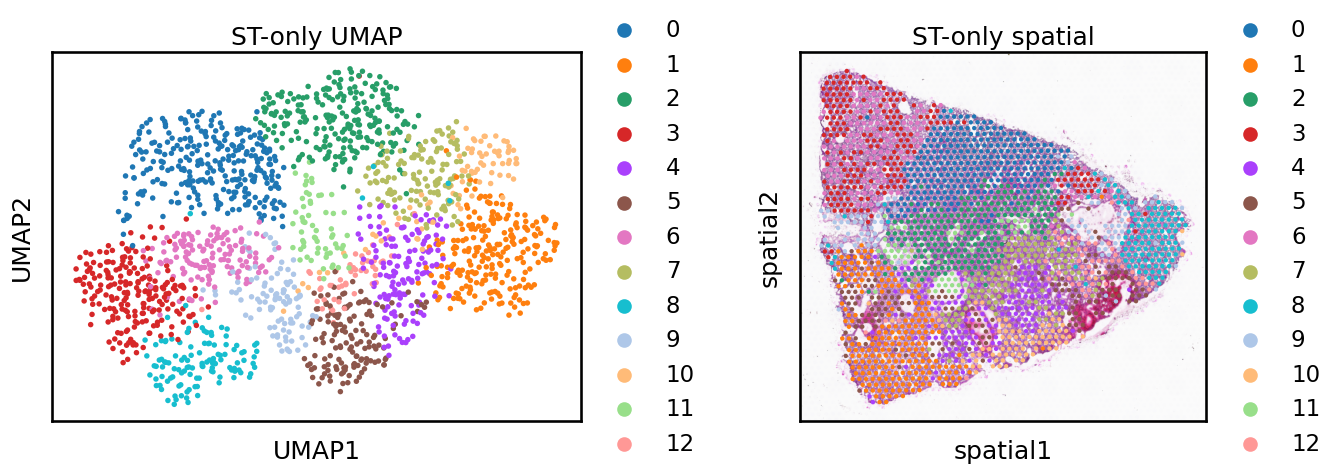

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata_ST_run, color=PRED_KEY_ST, ax=axes[0], show=False, title='ST-only UMAP')
sc.pl.spatial(adata_ST_run, color=PRED_KEY_ST, ax=axes[1], show=False, title='ST-only spatial')

plt.tight_layout()
plt.show()

In [56]:
adata_ST_run.obs['grid_key'] = (adata_ST_run.obs['array_row'].astype(str) + '_' + 
                                adata_ST_run.obs['array_col'].astype(str))

# Transfer annotation
adata_ST_run.obs['pathological_annotation'] = (
    adata_ST_run.obs['grid_key']
               .map(gt_annotation['pathological_annotation'])
)
adata_ST_run.obs['pathological_annotation'] = (
    adata_ST_run.obs['pathological_annotation'].astype('category')
)

# Clean up the helper column
adata_ST_run.obs.drop(columns=['grid_key'], inplace=True)

missing_mask = adata_ST_run.obs['pathological_annotation'].isna()
adata_ST_run_annotated = adata_ST_run[~missing_mask].copy()

# Remove NaN from the category levels themselves (categorical dtype retains them)
adata_ST_run_annotated.obs['pathological_annotation'] = (
    adata_ST_run_annotated.obs['pathological_annotation']
                         .cat.remove_unused_categories()
)

In [57]:
# --- Reconstruction ---
pcc_ST_run = compute_mean_pcc(adata_ST_run, reconstruction_layer='reconstruction')
cs_ST_run = compute_mean_cs(adata_ST_run, original_layer='counts', reconstruction_layer='reconstruction')

# --- Continuity ---
chaos_ST_run = compute_CHAOS(adata_ST_run, pred_key=PRED_KEY_ST, spatial_key='spatial')
pas_ST_run   = compute_PAS(adata_ST_run,   pred_key=PRED_KEY_ST, spatial_key='spatial')

# --- Marker score (ST features only, no SM subset needed) ---
moranI_ST_run, gearyC_ST_run = marker_score(adata_ST_run, domain_key=PRED_KEY_ST, top_n=50)

# --- Feature informativeness ---
spec_ST_run     = calculate_gene_specificity(adata_ST_run,         domain_key=PRED_KEY_ST, layers='counts')
logistic_ST_run = logistic_regression_feature_importance(adata_ST_run, domain_key=PRED_KEY_ST, layers='counts')
mi_ST_run       = calculate_mutual_information(adata_ST_run,       domain_key=PRED_KEY_ST, layers='counts')

# --- Biological conservation ---
ari_ST_run         = compute_ARI(adata_ST_run_annotated, gt_key=GT_KEY, pred_key=PRED_KEY_ST)
nmi_ST_run         = compute_NMI(adata_ST_run_annotated, gt_key=GT_KEY, pred_key=PRED_KEY_ST)
asw_spatial_ST_run = compute_ASW(adata_ST_run,        pred_key=PRED_KEY_ST, spatial_key='spatial')
#asw_emb_ST_run     = compute_gt_silhouette(adata_ST_run_annotated, gt_key=GT_KEY, embedding_key=EMB_KEY)
clisi_ST_run       = compute_clisi_graph(adata_ST_run_annotated,   gt_key=GT_KEY, embedding_key=EMB_KEY)

print("ST-only benchmarking done")

Mean PCC across 2000 features: 0.4590
Mean Cosine Similarity across 2000 features: 0.7229


100%|██████████| 100/100 [00:00<00:00, 302.41/s]


ST-only benchmarking done


## SM-only run

In [58]:
adata_SM_run = joint_adata[:, joint_adata.var['type'] == 'SM'].copy()

print(f"SM-only shape: {adata_SM_run.shape}")  

SM-only shape: (1914, 1299)


In [59]:
# Step 1: Remove noise genes
adata_SM_run = smt.pp.removeHSP_MT_RPL_DNAJ(adata_SM_run)

# Step 2: Save raw counts
adata_SM_run.layers['counts'] = adata_SM_run.X.copy()

# Step 3: Normalize (SM target_sum ignored since no SM features)
smt.pp.normalize_total_joint_adata_sm_st(
    adata_SM_run,
    target_sum_ST=1e4,
    target_sum_SM=1e4
)
adata_SM_run.layers['normalized'] = adata_SM_run.X.copy()
adata_SM_run.raw = adata_SM_run

# Step 4: HVF selection (n_top_metabolites=0 since no SM features)
smt.pp.spatial_variable(
    adata_SM_run,
    n_top_variable =2000,
    add_key='highly_variable_moranI'
)
adata_SM_run = adata_SM_run[:, adata_SM_run.var.highly_variable_moranI]

print(f"ST-only shape af pre-processing: {adata_SM_run.shape}")  # expect (n_spots, 2000)

ST-only shape af pre-processing: (1914, 1252)


In [60]:
model_SM = smt.model.ConditionalVAESTSM(
    adata_SM_run,
    device="cpu",
    reconstruction_method_st='zinb',
    reconstruction_method_sm='g'
)

model_SM.fit(
    max_epoch=64,
    lr=1e-3,
    mode='single',
    reconstruction_st_weight=0.0,
    reconstruction_sm_weight=1.0 
)

adata_SM_run.obsm['X_emb'] = model_SM.get_latent_embedding()
adata_SM_run.layers['reconstruction'] = model_SM.get_normalized_expression()

Normalized Expression: 100%|██████████| 15/15 [00:00<00:00, 105.35it/s]


In [61]:
sc.pp.neighbors(adata_SM_run, use_rep='X_emb', n_neighbors=N_NEIGH)
sc.tl.umap(adata_SM_run, min_dist=1, spread=1)
sc.tl.leiden(adata_SM_run, key_added='SM_clusters')

PRED_KEY_SM = 'SM_clusters'

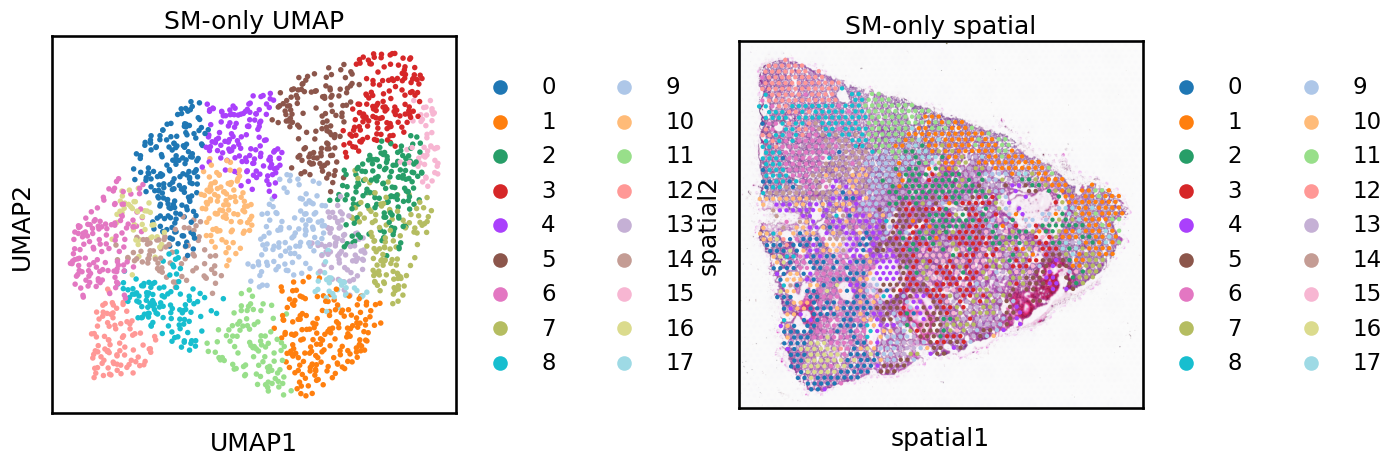

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.umap(adata_SM_run, color=PRED_KEY_SM, ax=axes[0], show=False, title='SM-only UMAP')
sc.pl.spatial(adata_SM_run, color=PRED_KEY_SM, ax=axes[1], show=False, title='SM-only spatial')

plt.tight_layout()
plt.show()

In [63]:
adata_SM_run.obs['grid_key'] = (adata_SM_run.obs['array_row'].astype(str) + '_' + 
                                adata_SM_run.obs['array_col'].astype(str))

# Transfer annotation
adata_SM_run.obs['pathological_annotation'] = (
    adata_SM_run.obs['grid_key']
               .map(gt_annotation['pathological_annotation'])
)
adata_SM_run.obs['pathological_annotation'] = (
    adata_SM_run.obs['pathological_annotation'].astype('category')
)

# Clean up the helper column
adata_SM_run.obs.drop(columns=['grid_key'], inplace=True)

missing_mask = adata_SM_run.obs['pathological_annotation'].isna()
adata_SM_run_annotated = adata_SM_run[~missing_mask].copy()

# Remove NaN from the category levels themselves (categorical dtype retains them)
adata_SM_run_annotated.obs['pathological_annotation'] = (
    adata_SM_run_annotated.obs['pathological_annotation']
                         .cat.remove_unused_categories()
)

In [64]:
# --- Reconstruction ---
pcc_SM_run = compute_mean_pcc(adata_SM_run, reconstruction_layer='reconstruction')
cs_SM_run = compute_mean_cs(adata_SM_run, original_layer='counts', reconstruction_layer='reconstruction')

# --- Continuity ---
chaos_SM_run = compute_CHAOS(adata_SM_run, pred_key=PRED_KEY_SM, spatial_key='spatial')
pas_SM_run   = compute_PAS(adata_SM_run,   pred_key=PRED_KEY_SM, spatial_key='spatial')

# --- Marker score (SM features only) ---
adata_SM_run_ms = adata_SM_run.copy()
adata_SM_run_ms.obs[PRED_KEY_SM] = adata_SM_run_ms.obs[PRED_KEY_SM].astype('category')
moranI_SM_run, gearyC_SM_run = marker_score(adata_SM_run_ms, domain_key=PRED_KEY_SM, top_n=50)

# --- Feature informativeness ---
spec_SM_run     = calculate_gene_specificity(adata_SM_run_ms,         domain_key=PRED_KEY_SM, layers='counts')
logistic_SM_run = logistic_regression_feature_importance(adata_SM_run_ms, domain_key=PRED_KEY_SM, layers='counts')
mi_SM_run       = calculate_mutual_information(adata_SM_run_ms,       domain_key=PRED_KEY_SM, layers='counts')

# --- Biological conservation ---
ari_SM_run         = compute_ARI(adata_SM_run_annotated, gt_key=GT_KEY, pred_key=PRED_KEY_SM)
nmi_SM_run         = compute_NMI(adata_SM_run_annotated, gt_key=GT_KEY, pred_key=PRED_KEY_SM)
asw_spatial_SM_run = compute_ASW(adata_SM_run,        pred_key=PRED_KEY_SM, spatial_key='spatial')
#asw_emb_SM_run     = compute_gt_silhouette(adata_SM_run_annotated, gt_key=GT_KEY, embedding_key=EMB_KEY)
clisi_SM_run       = compute_clisi_graph(adata_SM_run_annotated,   gt_key=GT_KEY, embedding_key=EMB_KEY)

print("SM-only benchmarking done")

Mean PCC across 1252 features: 0.2260
Mean Cosine Similarity across 1252 features: 0.5059


100%|██████████| 100/100 [00:00<00:00, 288.21/s]


SM-only benchmarking done


## Comparison: Joint vs ST-only vs SM-only

In [65]:
import pandas as pd
import numpy as np

def make_results_row(label,
                     chaos, pas,
                     moranI, gearyC,
                     spec, logistic, mi,
                     asw, clisi,
                     ari, nmi,
                     pcc, cs):
    continuity   = ((1 - chaos) + (1 - pas)) / 2
    marker       = (moranI + (1 - gearyC) + spec + mi) / 4
    bio_cons     = (asw + ari + nmi + clisi) / 4
    recon        = (pcc + cs) / 2  # NaN for PCA-based runs

    return {
        'Method':             label,
        'PCC':                pcc,
        'CosineSim':          cs,
        'CHAOS':              chaos,
        'PAS':                pas,
        'MoranI':             moranI,
        'GearyC':             gearyC,
        'Specificity':        spec,
        'Logistic':           logistic,
        'MutualInfo':         mi,
        'ASW':                asw,
        'cLISI':              clisi,
        'Adjusted Rand Index': ari,
        'NMI':                nmi,
        # Scores
        'Reconstruction':     recon,
        'Continuity':         continuity,
        'Marker':             marker,
        'BioConservation':    bio_cons,
    }

rows = [
    make_results_row('SpatialMETA',
                     chaos_score, pas_score,
                     moranI, gearyC,     
                     specificity, logistic, mi,
                     asw, clisi,
                     ari, nmi,
                     mean_pcc, mean_cs),

    make_results_row('ST-only',
                     chaos_ST_run, pas_ST_run,
                     moranI_ST_run, gearyC_ST_run,
                     spec_ST_run, logistic_ST_run, mi_ST_run,
                     asw_spatial_ST_run, clisi_ST_run,
                     ari_ST_run, nmi_ST_run,
                     pcc_ST_run, cs_ST_run),

    make_results_row('SM-only',
                     chaos_SM_run, pas_SM_run,
                     moranI_SM_run, gearyC_SM_run,
                     spec_SM_run, logistic_SM_run, mi_SM_run,
                     asw_spatial_SM_run, clisi_SM_run,
                     ari_SM_run, nmi_SM_run,
                     pcc_SM_run, cs_SM_run),
]

comparison_df = pd.DataFrame(rows).set_index('Method')
comparison_df

,PCC,CosineSim,CHAOS,PAS,MoranI,GearyC,Specificity,Logistic,MutualInfo,ASW,cLISI,Adjusted Rand Index,NMI,Reconstruction,Continuity,Marker,BioConservation
Method,,,,,,,,,,,,,,,,,
SpatialMETA,0.451552,0.705025,0.088689,0.354754,0.523378,0.468815,1.957469,0.770235,0.104304,-0.026898,0.919472,0.392340,0.557215,0.578289,0.778278,0.779084,0.460533
ST-only,0.458992,0.722913,0.087455,0.288401,0.151524,0.845996,1.426270,0.723238,0.071253,0.007686,0.904660,0.406428,0.546472,0.590953,0.812072,0.450763,0.466311
SM-only,0.225952,0.505931,0.093825,0.540230,0.584441,0.408618,2.223468,0.545692,0.111940,-0.132619,0.847556,0.184078,0.388039,0.365941,0.682973,0.877808,0.321764


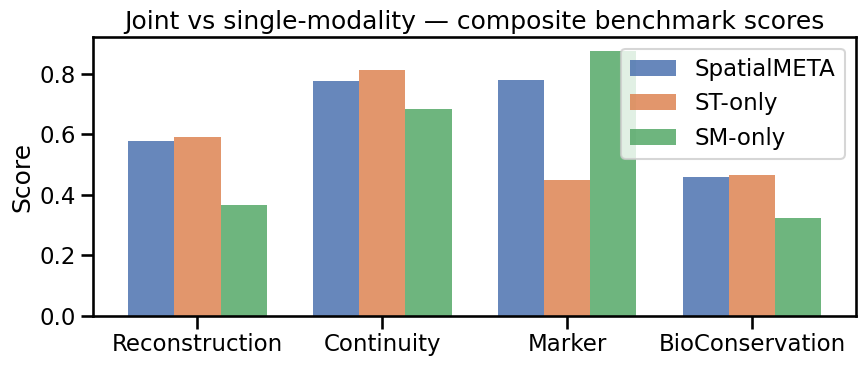

In [66]:
composite_cols = ['Reconstruction', 'Continuity', 'Marker', 'BioConservation']
plot_df = comparison_df[composite_cols].copy()

fig, ax = plt.subplots(figsize=(9, 4))

x = range(len(composite_cols))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (method, row) in enumerate(plot_df.iterrows()):
    ax.bar([xi + i * width for xi in x], row.values,
           width=width, label=method, color=colors[i], alpha=0.85)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(composite_cols)
ax.set_ylabel('Score')
ax.set_title('Joint vs single-modality — composite benchmark scores')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [67]:
comparison_df

,PCC,CosineSim,CHAOS,PAS,MoranI,GearyC,Specificity,Logistic,MutualInfo,ASW,cLISI,Adjusted Rand Index,NMI,Reconstruction,Continuity,Marker,BioConservation
Method,,,,,,,,,,,,,,,,,
SpatialMETA,0.451552,0.705025,0.088689,0.354754,0.523378,0.468815,1.957469,0.770235,0.104304,-0.026898,0.919472,0.392340,0.557215,0.578289,0.778278,0.779084,0.460533
ST-only,0.458992,0.722913,0.087455,0.288401,0.151524,0.845996,1.426270,0.723238,0.071253,0.007686,0.904660,0.406428,0.546472,0.590953,0.812072,0.450763,0.466311
SM-only,0.225952,0.505931,0.093825,0.540230,0.584441,0.408618,2.223468,0.545692,0.111940,-0.132619,0.847556,0.184078,0.388039,0.365941,0.682973,0.877808,0.321764
